# Stage 10: Pseudobulk Differential Expression and Positive-Control Evaluation

## Stage Objective

Quantify exercise-associated transcriptional changes by cell type and evaluate recovery of pre-registered biological positive controls.

## Workflow

| Step | Operation | Analytical purpose |
|------|-----------|--------------------|
| 1 | Pseudobulk assembly | Aggregate cell-type-resolved expression at the sample level. |
| 2 | Differential modeling | Fit sex-stratified limma-trend contrasts and apply global false-discovery-rate control. |
| 3 | Hotspot identification | Summarize cell-type blocks with concentrated evidence of exercise response. |
| 4 | Positive-control comparison | Compare detected genes and pathways with the frozen Tier A reference set. |

## Inputs and Outputs

| Component | Description |
|-----------|-------------|
| Inputs | Stage 8 pseudo-cell expression and sample metadata, plus the pre-registered positive-control specification. |
| Primary outputs | Differential-expression tables, hotspot summaries, and positive-control comparison reports. |

## Result Overview

The analysis reports both recovered and unrecovered controls, avoiding interpretation based only on significant findings.

The sections below present the computational evidence in execution order. All reported figures are generated from the recorded stage outputs rather than manually entered plotting values unless explicitly identified as configuration constants.


In [9]:
from pathlib import Path

DE_DIR = Path("../data/deconvolution/genecompass_input/pseudobulk_de")
tissues = ["BLOOD","CORTEX","HEART","HIPPOC","KIDNEY","LIVER","LUNG","SKMGN","SKMVL","WATSC"]

print("=== Global outputs ===")
for f in ["de_summary.tsv","de_hotspots.tsv","de_methods.tsv",
          "posctrl_results.tsv","posctrl_responsiveness.tsv","posctrl_summary.md",
          "dominant_celltype_flags.tsv"]:
    p = DE_DIR / f
    size = f"{p.stat().st_size/1e3:.1f} KB" if p.exists() else "MISSING"
    rows = sum(1 for _ in p.open()) - 1 if p.exists() and f.endswith(".tsv") else ""
    print(f"  {f:<40} {size:>12}  {str(rows)+' rows' if rows else ''}")

print()
print("=== Per-tissue DE files ===")
for t in tissues:
    d = DE_DIR / t
    n = len(list(d.glob("de__*.tsv"))) if d.exists() else 0
    total_kb = sum(f.stat().st_size for f in d.glob("de__*.tsv")) / 1e3 if d.exists() else 0
    print(f"  {t:<10}  {n:>3} cell-type DE files  ({total_kb:>7.0f} KB total)")


=== Global outputs ===
  de_summary.tsv                                29.8 KB  185 rows
  de_hotspots.tsv                                3.9 KB  21 rows
  de_methods.tsv                                 0.4 KB  6 rows
  posctrl_results.tsv                           16.3 KB  81 rows
  posctrl_responsiveness.tsv                     3.0 KB  23 rows
  posctrl_summary.md                            12.2 KB  
  dominant_celltype_flags.tsv                    0.5 KB  10 rows

=== Per-tissue DE files ===
  BLOOD        14 cell-type DE files  (  72870 KB total)
  CORTEX       36 cell-type DE files  ( 227399 KB total)
  HEART        23 cell-type DE files  ( 137025 KB total)
  HIPPOC       15 cell-type DE files  ( 109986 KB total)
  KIDNEY       16 cell-type DE files  ( 100752 KB total)
  LIVER         6 cell-type DE files  (  33688 KB total)
  LUNG         34 cell-type DE files  ( 175064 KB total)
  SKMGN        17 cell-type DE files  (  97990 KB total)
  SKMVL        16 cell-type DE files  (  964

## Step 1 — Per-cell-type Pseudobulk DE (limma-trend)

`run_pseudobulk_de.sh` runs the Vetr-faithful pseudobulk DE pipeline on BayesPrism posterior Z matrices. For each (tissue, cell type) block independently:

1. **Input**: `pred_z/predz__<CellType>.csv` — 50 samples × genes, count-scale Z
2. **Filter**: drop all-zero genes; keep genes with ≥ 1 non-zero count in ≥ 3 samples
3. **Normalization**: TMM + `voom` precision weights → per-cell-type library sizes reflect BayesPrism Z scale
4. **Models fit** (per sex separately):
   - `~ 0 + factor(week)` → per-timepoint contrasts (1w, 2w, 4w, 8w vs. sedentary)
   - `~ week` → ordinal slope (linear dose–response)
   - `~ sex * week` interaction → sex-differential response
5. **Sex-combine**: Fisher meta-p of male + female per-timepoint p-values, then Storey BH per block
6. **Global FDR**: IHW with covariate = tissue, pooling all Fisher meta-p across all 185 blocks
7. **Sex-consistency at 8w**: `repfdr(replication) × sign` — genes must be significant in both sexes with concordant direction

**Hotspot criterion**: a block is flagged `is_hotspot=TRUE` if `q_sup_trained < 0.05` (the Augur AUC permutation p-value for the `trained` contrast in the Stage 9 GeneCompass embeddings). This links the embedding-level signal (Stage 9) to the gene-level DE (Stage 10).


In [10]:
import pandas as pd

DE_DIR = "../data/deconvolution/genecompass_input/pseudobulk_de"
de = pd.read_csv(f"{DE_DIR}/de_summary.tsv", sep="\t")

print(f"Total blocks: {len(de)}  |  Hotspots: {de.is_hotspot.sum()}  |  Tissues: {de.tissue.nunique()}")
print()

# Per-tissue summary
ts = de.groupby("tissue").agg(
    blocks=("cell_type","count"),
    hotspots=("is_hotspot","sum"),
    sig_IHW=("n_sig_dose_IHW","sum"),
    sig_fisher=("n_sig_dose_fisher_BHblock","sum"),
    sig_sex=("n_sig_sex","sum"),
    n_interaction=("n_sig_interaction","sum"),
).reset_index().sort_values("sig_IHW", ascending=False)

ts["hotspot_rate"] = (ts.hotspots / ts.blocks).map(lambda x: f"{x:.0%}")
print(ts[["tissue","blocks","hotspots","hotspot_rate","sig_IHW","sig_fisher","sig_sex","n_interaction"]]
      .rename(columns={"sig_IHW":"DE (IHW)","sig_fisher":"DE (Fisher-BH)",
                        "sig_sex":"DE (sex)","n_interaction":"intxn"})
      .to_string(index=False))


Total blocks: 185  |  Hotspots: 21  |  Tissues: 10

tissue  blocks  hotspots hotspot_rate  DE (IHW)  DE (Fisher-BH)  DE (sex)  intxn
 BLOOD      14         7          50%     12664           17245     12092      2
  LUNG      34         3           9%      7152           12956     11890   6005
 SKMGN      17         5          29%      2128            2902     12135     13
 SKMVL      14         4          29%      1698            2639      6956     11
 HEART      23         1           4%       770            3362     16960      9
 LIVER       6         0           0%       426             435     27206      7
 WATSC      17         0           0%        69             651     97164     15
KIDNEY      17         1           6%        16              35     62426      2
CORTEX      28         0           0%         3              14        48      5
HIPPOC      15         0           0%         1               8         9      0


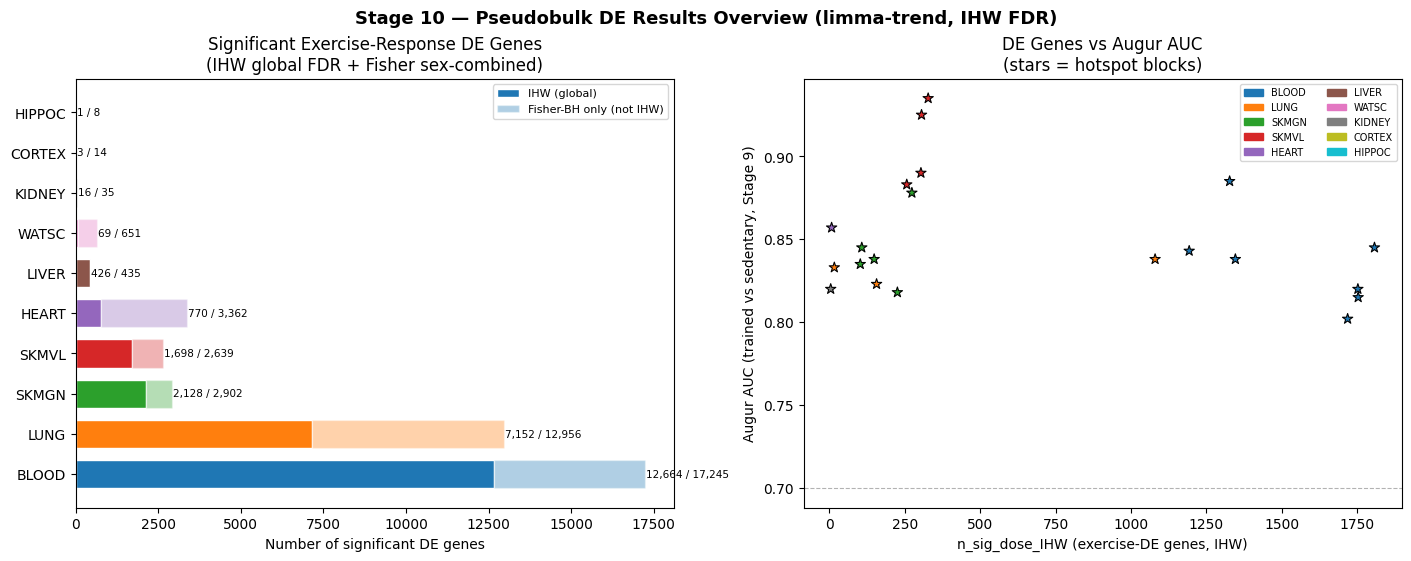

In [19]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DE_DIR = Path("../data/deconvolution/genecompass_input/pseudobulk_de")
de = pd.read_csv(DE_DIR / "de_summary.tsv", sep="\t")

ts = de.groupby("tissue").agg(
    blocks=("cell_type","count"),
    hotspots=("is_hotspot","sum"),
    sig_IHW=("n_sig_dose_IHW","sum"),
    sig_fisher=("n_sig_dose_fisher_BHblock","sum"),
).reset_index().sort_values("sig_IHW", ascending=False)

tissues_ord = ts.tissue.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(tissues_ord)))
color_map = dict(zip(tissues_ord, colors))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
fig.suptitle("Stage 10 — Pseudobulk DE Results Overview (limma-trend, IHW FDR)", fontsize=13, fontweight="bold")

# Left: sig_IHW and sig_fisher stacked per tissue
y = np.arange(len(tissues_ord))
ax1.barh(y, ts.sig_IHW,    height=0.7, color=[color_map[t] for t in tissues_ord],
         edgecolor="white", label="IHW (global)")
ax1.barh(y, ts.sig_fisher - ts.sig_IHW, height=0.7,
         left=ts.sig_IHW,
         color=[color_map[t] for t in tissues_ord], edgecolor="white",
         alpha=0.35, label="Fisher-BH only (not IHW)")
for i, (a, b) in enumerate(zip(ts.sig_IHW, ts.sig_fisher)):
    ax1.text(b + 30, i, f"{a:,} / {b:,}", va="center", fontsize=7.5)
ax1.set_yticks(y)
ax1.set_yticklabels(tissues_ord)
ax1.set_xlabel("Number of significant DE genes")
ax1.set_title("Significant Exercise-Response DE Genes\n(IHW global FDR + Fisher sex-combined)")
ax1.legend(fontsize=8, loc="upper right")

# Right: hotspots vs non-hotspots scatter (n_sig_IHW vs Augur AUC)
hot = de[de.is_hotspot]
non = de[~de.is_hotspot]
sc1 = ax2.scatter(non.n_sig_dose_IHW, non.sup_trained_auc,
                  c=[color_map.get(t, "gray") for t in non.tissue],
                  alpha=0.5, s=30, label="non-hotspot")
sc2 = ax2.scatter(hot.n_sig_dose_IHW, hot.sup_trained_auc,
                  c=[color_map.get(t, "black") for t in hot.tissue],
                  edgecolors="black", linewidths=0.8, s=60, marker="*",
                  label="hotspot (q_sup_trained<0.05)")
ax2.axhline(0.7, color="gray", lw=0.8, ls="--", alpha=0.6, label="AUC=0.7")
ax2.set_xlabel("n_sig_dose_IHW (exercise-DE genes, IHW)")
ax2.set_ylabel("Augur AUC (trained vs sedentary, Stage 9)")
ax2.set_title("DE Genes vs Augur AUC\n(stars = hotspot blocks)")
ax2.legend(fontsize=8, loc="upper right")

# Add tissue color legend
from matplotlib.patches import Patch
legend_els = [Patch(color=color_map[t], label=t) for t in tissues_ord]
ax2.legend(handles=legend_els, fontsize=7, ncol=2, loc="upper right")

plt.show()


## Hotspot Blocks

A tissue-by-cell-type block is designated a hotspot when the supervised GeneCompass embedding probe satisfies `q_sup_trained < 0.05` after BH correction across all testable blocks.

The adopted rerun identifies **21 hotspots among 185 blocks**: blood 7, skmgn 5, skmvl 4, lung 3, heart 1, and kidney 1. The native lung reference therefore changes the Stage 10 conclusion: lung now contributes three exercise hotspots, whereas liver remains without a hotspot.


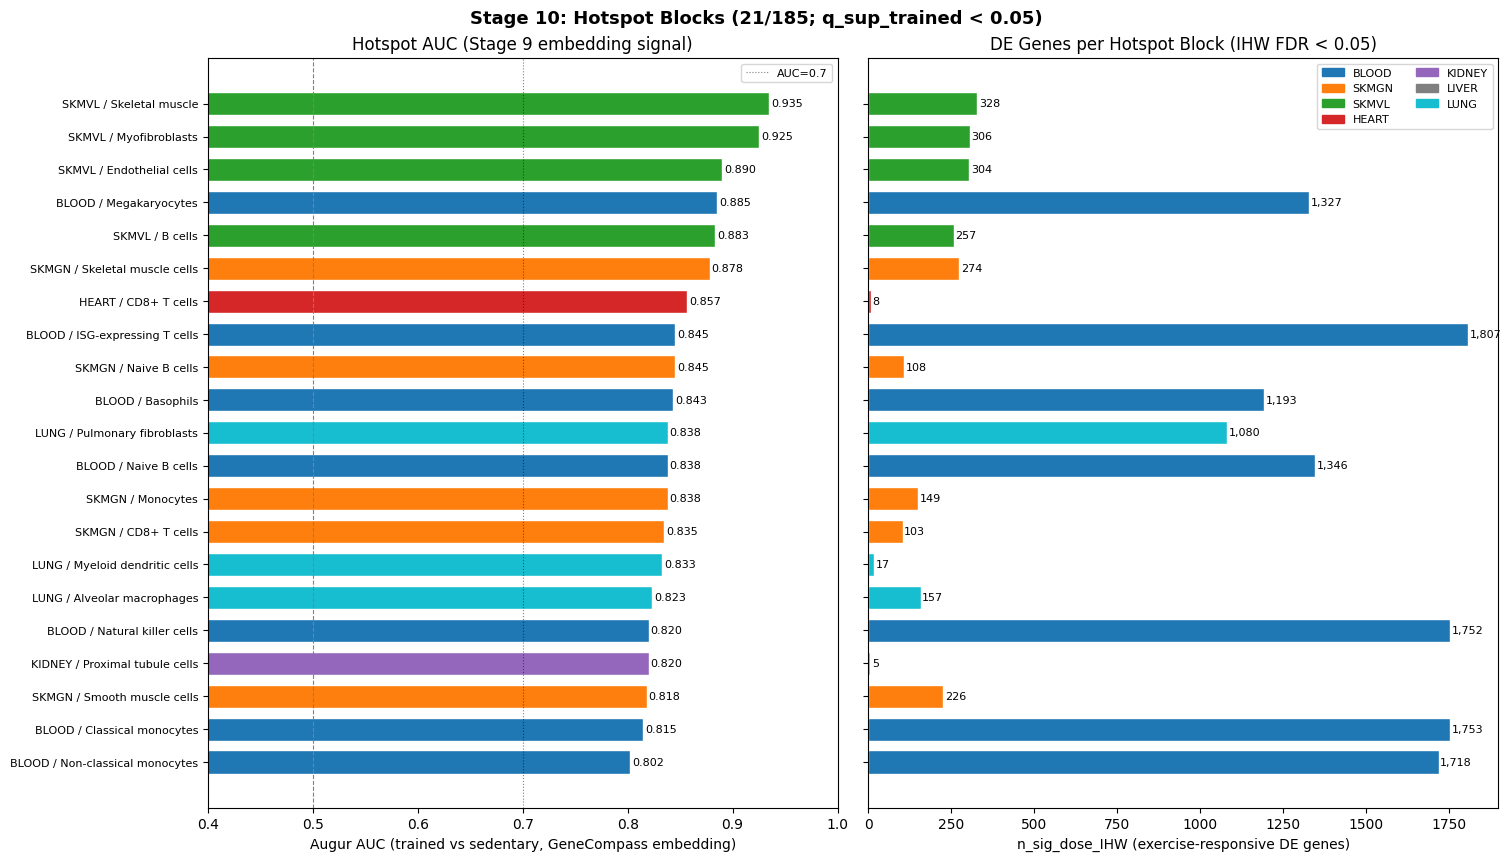

In [20]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DE_DIR = Path("../data/deconvolution/genecompass_input/pseudobulk_de")
de = pd.read_csv(DE_DIR / "de_summary.tsv", sep="\t")
hot = de[de.is_hotspot].sort_values("sup_trained_auc", ascending=True).reset_index(drop=True)

tissue_colors = {
    "BLOOD":"#1f77b4","SKMGN":"#ff7f0e","SKMVL":"#2ca02c",
    "HEART":"#d62728","KIDNEY":"#9467bd",
    "LIVER":"#7f7f7f","LUNG":"#17becf",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8.5), constrained_layout=True)
fig.suptitle(f"Stage 10: Hotspot Blocks ({len(hot)}/{len(de)}; q_sup_trained < 0.05)",
             fontsize=13, fontweight="bold")

y = np.arange(len(hot))
label = [f"{r.tissue} / {r.cell_type}" for _, r in hot.iterrows()]
bar_colors = [tissue_colors.get(r.tissue, "gray") for _, r in hot.iterrows()]

# Left: Augur AUC
ax1.barh(y, hot.sup_trained_auc, color=bar_colors, edgecolor="white", height=0.7)
ax1.axvline(0.5, color="gray", lw=0.8, ls="--")
ax1.axvline(0.7, color="black", lw=0.8, ls=":", alpha=0.5, label="AUC=0.7")
for i, v in enumerate(hot.sup_trained_auc):
    ax1.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
ax1.set_yticks(y)
ax1.set_yticklabels(label, fontsize=8)
ax1.set_xlabel("Augur AUC (trained vs sedentary, GeneCompass embedding)")
ax1.set_title("Hotspot AUC (Stage 9 embedding signal)")
ax1.set_xlim(0.4, 1.0)
ax1.legend(fontsize=8)

# Right: IHW-significant DE genes
ax2.barh(y, hot.n_sig_dose_IHW, color=bar_colors, edgecolor="white", height=0.7)
for i, v in enumerate(hot.n_sig_dose_IHW):
    ax2.text(v + 5, i, f"{v:,}", va="center", fontsize=8)
ax2.set_yticks(y)
ax2.tick_params(axis="y", labelleft=False)
ax2.set_xlabel("n_sig_dose_IHW (exercise-responsive DE genes)")
ax2.set_title("DE Genes per Hotspot Block (IHW FDR < 0.05)")

# Tissue color legend
from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=t) for t, c in tissue_colors.items()]
ax2.legend(handles=legend_els, fontsize=8, loc="upper right", ncol=2)

plt.show()


## Step 2 — Pre-registered Positive-control Comparison

`compare_posctrl.py` executes the **frozen pre-registration** (`posctrl_prereg.tsv`) against the DE results. Outcomes follow a **miss-ladder** in priority order:

| Outcome | Meaning |
|---------|---------|
| `not_testable_prior` | Gene absent from GeneCompass vocabulary or cell type not resolved |
| `not_testable` | Gene filtered (all-zero) in this tissue × cell type |
| `underpowered` | `mean_fraction < 0.01` or `n_nonzero < 25` |
| `not_significant` | Testable and powered, but FDR ≥ α |
| `wrong_direction` | Significant (FDR < α) but direction is opposite to expectation |
| `recovered` | Significant in the expected direction |
| `recovered_confounded` | Significant but with potential confound |

**Three tiers** of positive controls test different aspects of specificity:

- **Tier A** — direction-anchored: muscle mitochondrial biogenesis genes (up, 8w), heart mitochondrial genes (up), metabolic regulators. Tests that BayesPrism + limma recovers known exercise-responsive biology.
- **Tier Ai** — identity-only: cell-type marker genes (e.g., cardiomyocyte markers in heart) that should be detectable but have no expected direction of exercise response.
- **Tier B** — Vetr et al. named findings: specific gene × tissue × sex × cell-type combinations reported in the MoTrPAC pilot study.
- **Tier C** — Yu immune programs: gene set enrichment of exercise-responsive immune programs in blood cell types.


In [13]:
import pandas as pd
from pathlib import Path

DE_DIR = Path("../data/deconvolution/genecompass_input/pseudobulk_de")
pr = pd.read_csv(DE_DIR / "posctrl_results.tsv", sep="\t")

print("=== Positive-control outcomes by tier ===")
pivot = pr.groupby(["tier","outcome"]).size().unstack(fill_value=0)
print(pivot.to_string())

print()
print("=== Recovered and wrong_direction entries ===")
notable = pr[pr.outcome.isin(["recovered","recovered_confounded","wrong_direction"])].copy()
notable["lfc_8w"] = notable["lfc_8w"].map(lambda x: f"{x:+.3f}" if pd.notna(x) else "NA")
notable["FDR_IHW"] = notable["FDR_IHW"].map(lambda x: f"{x:.4f}" if pd.notna(x) else "NA")
print(notable[["tier","group","symbol","tissue","cell_type","sex","expected_dir",
               "FDR_IHW","lfc_8w","outcome"]].to_string(index=False))


=== Positive-control outcomes by tier ===
outcome  not_significant  not_testable  not_testable_prior  recovered  recovered_confounded  wrong_direction
tier                                                                                                        
A                     36             3                   1          3                     0                2
Ai                    14             0                   0          0                     0                0
B                      8             4                   2          6                     2                0

=== Recovered and wrong_direction entries ===
tier                  group   symbol tissue                cell_type    sex expected_dir FDR_IHW lfc_8w              outcome
   A muscle_mito_biogenesis     Mfn1  SKMGN    Skeletal muscle cells    any           up  0.0491 +0.054            recovered
   A muscle_mito_biogenesis   Tbc1d1  SKMGN    Skeletal muscle cells    any           up  0.0268 +0.165            r

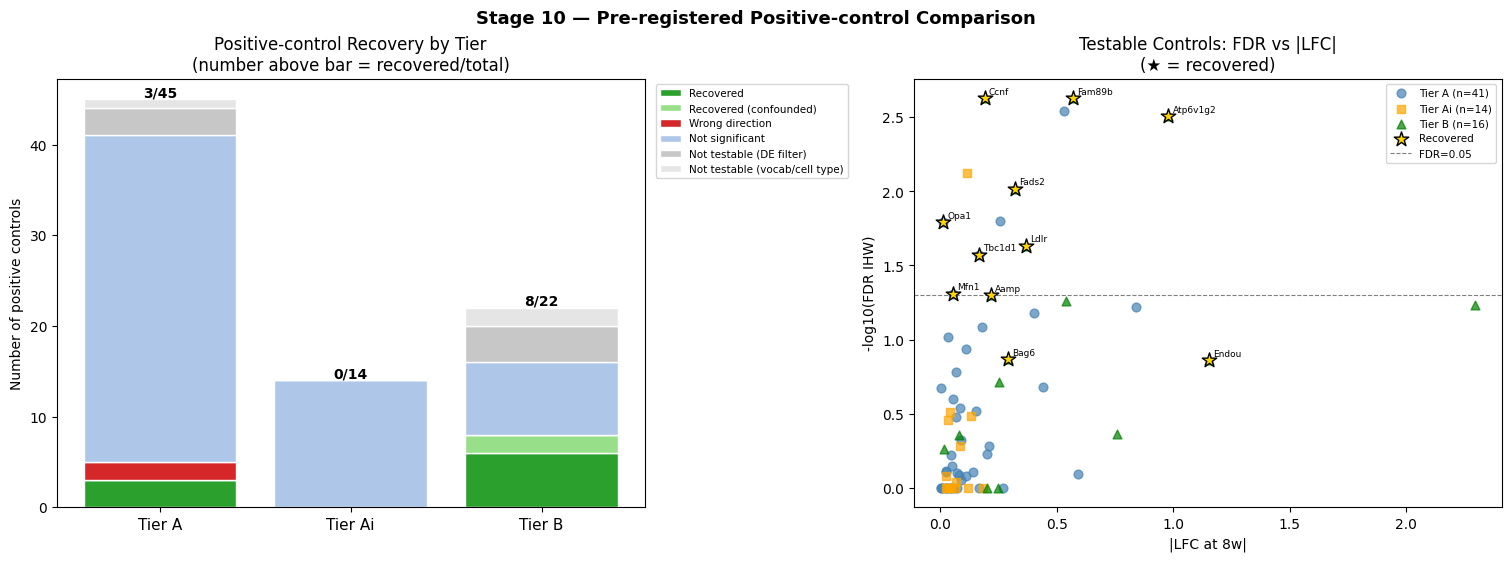

In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DE_DIR = Path("../data/deconvolution/genecompass_input/pseudobulk_de")
pr = pd.read_csv(DE_DIR / "posctrl_results.tsv", sep="\t")

tier_order   = ["A", "Ai", "B"]
outcome_cats = ["recovered","recovered_confounded","wrong_direction",
                "not_significant","not_testable","not_testable_prior"]
outcome_colors = {
    "recovered":           "#2ca02c",
    "recovered_confounded":"#98df8a",
    "wrong_direction":     "#d62728",
    "not_significant":     "#aec7e8",
    "not_testable":        "#c7c7c7",
    "not_testable_prior":  "#e5e5e5",
}
outcome_labels = {
    "recovered": "Recovered",
    "recovered_confounded": "Recovered (confounded)",
    "wrong_direction": "Wrong direction",
    "not_significant": "Not significant",
    "not_testable": "Not testable (DE filter)",
    "not_testable_prior": "Not testable (vocab/cell type)",
}

counts = pr.groupby(["tier","outcome"]).size().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
fig.suptitle("Stage 10 — Pre-registered Positive-control Comparison", fontsize=13, fontweight="bold")

# Left: stacked bar per tier
tier_totals = []
x = np.arange(len(tier_order))
bottoms = np.zeros(len(tier_order))
for oc in outcome_cats:
    vals = [counts.loc[t, oc] if oc in counts.columns and t in counts.index else 0
            for t in tier_order]
    ax1.bar(x, vals, bottom=bottoms,
            color=outcome_colors[oc], label=outcome_labels[oc], edgecolor="white")
    bottoms += np.array(vals)
for i, t in enumerate(tier_order):
    total = int(bottoms[i])
    rec   = int(counts.loc[t, "recovered"] if "recovered" in counts.columns and t in counts.index else 0)
    rec_c = int(counts.loc[t, "recovered_confounded"] if "recovered_confounded" in counts.columns and t in counts.index else 0)
    ax1.text(i, total + 0.3, f"{rec+rec_c}/{total}", ha="center", fontsize=10, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels([f"Tier {t}" for t in tier_order], fontsize=11)
ax1.set_ylabel("Number of positive controls")
ax1.set_title("Positive-control Recovery by Tier\n(number above bar = recovered/total)")
ax1.legend(fontsize=7.5, bbox_to_anchor=(1.01, 1), loc="upper left")

# Right: FDR vs |LFC| scatter for Tier A + B testable entries
testable = pr[pr.outcome.isin(["recovered","recovered_confounded","wrong_direction","not_significant"])].copy()
testable["abs_lfc"] = testable["lfc_8w"].abs()
testable["neg_log10_fdr"] = (-np.log10(testable["FDR_IHW"].clip(1e-5))).clip(0)
tier_mk = {"A": "o", "Ai": "s", "B": "^"}
tier_col = {"A": "steelblue", "Ai": "orange", "B": "green"}
for tier in ["A", "Ai", "B"]:
    sub = testable[testable.tier == tier]
    ax2.scatter(sub.abs_lfc, sub.neg_log10_fdr,
                marker=tier_mk[tier], color=tier_col[tier],
                s=40, alpha=0.7, label=f"Tier {tier} (n={len(sub)})")
# Highlight recovered
rec = testable[testable.outcome.isin(["recovered","recovered_confounded"])]
ax2.scatter(rec.abs_lfc, rec.neg_log10_fdr, marker="*",
            color="gold", edgecolors="black", s=120, zorder=5, label="Recovered")
ax2.axhline(-np.log10(0.05), color="gray", lw=0.8, ls="--", label="FDR=0.05")
for _, row in rec.iterrows():
    ax2.annotate(row["symbol"], (row["abs_lfc"], row["neg_log10_fdr"]),
                 fontsize=6.5, xytext=(3, 3), textcoords="offset points")
ax2.set_xlabel("|LFC at 8w|")
ax2.set_ylabel("-log10(FDR IHW)")
ax2.set_title("Testable Controls: FDR vs |LFC|\n(★ = recovered)")
ax2.legend(fontsize=7.5)

plt.show()


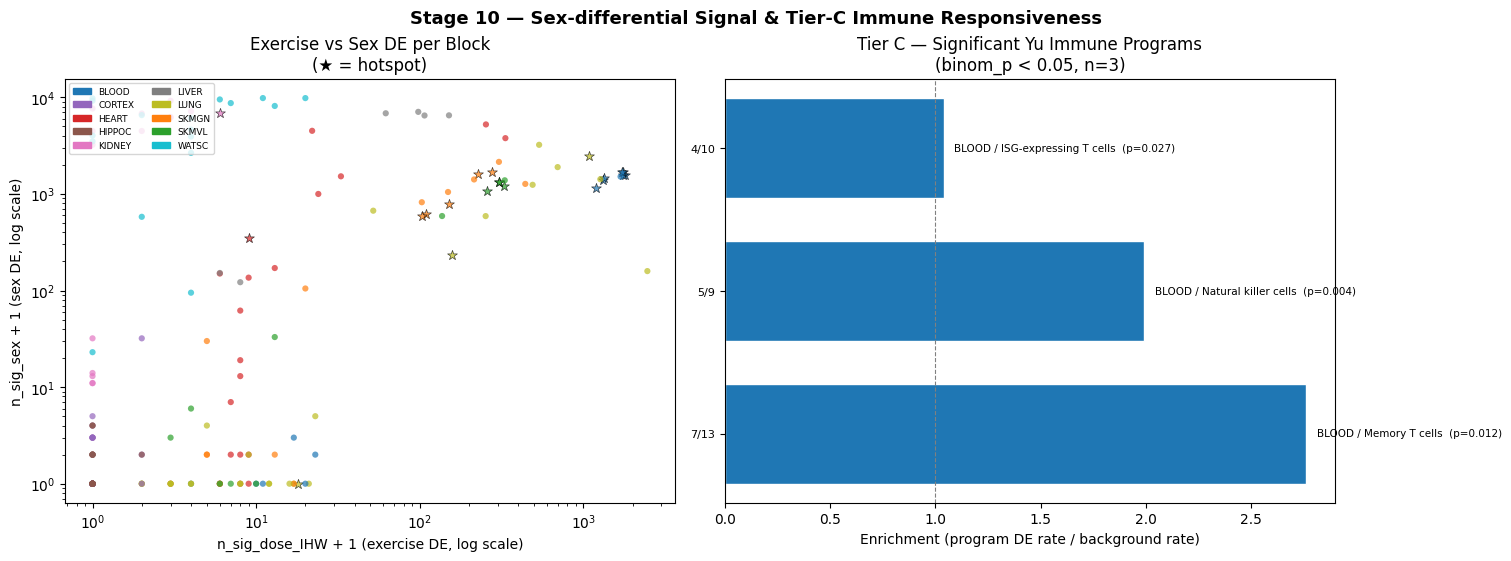

In [15]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DE_DIR = Path("../data/deconvolution/genecompass_input/pseudobulk_de")
de  = pd.read_csv(DE_DIR / "de_summary.tsv",      sep="\t")
pc  = pd.read_csv(DE_DIR / "posctrl_responsiveness.tsv", sep="\t")

tissue_colors = {
    "BLOOD":"#1f77b4","CORTEX":"#9467bd","HEART":"#d62728",
    "HIPPOC":"#8c564b","KIDNEY":"#e377c2","LIVER":"#7f7f7f",
    "LUNG":"#bcbd22","SKMGN":"#ff7f0e","SKMVL":"#2ca02c","WATSC":"#17becf",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
fig.suptitle("Stage 10 — Sex-differential Signal & Tier-C Immune Responsiveness", fontsize=13, fontweight="bold")

# Left: n_sig_sex vs n_sig_dose_IHW per block (log scale)
for _, row in de.iterrows():
    col = tissue_colors.get(row.tissue, "gray")
    mk  = "*" if row.is_hotspot else "o"
    ax1.scatter(row.n_sig_dose_IHW + 1, row.n_sig_sex + 1,
                c=col, marker=mk, s=(55 if row.is_hotspot else 20),
                alpha=0.7, edgecolors="black" if row.is_hotspot else "none",
                linewidths=0.5)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("n_sig_dose_IHW + 1 (exercise DE, log scale)")
ax1.set_ylabel("n_sig_sex + 1 (sex DE, log scale)")
ax1.set_title("Exercise vs Sex DE per Block\n(★ = hotspot)")
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color=c, label=t) for t, c in tissue_colors.items()],
           fontsize=6.5, ncol=2, loc="upper left")

# Right: Tier C Yu immune programs — enrichment per program
if len(pc) > 0:
    pc_tier_c = pc[pc.tier == "C"].copy() if "tier" in pc.columns else pc.copy()
    pc_agg = pc_tier_c.groupby(["tissue","cell_type"]).agg(
        n_DE=("n_DE","sum"),
        n_testable=("n_testable","sum"),
        enrichment=("enrichment","mean"),
        binom_p=("binom_p","min"),
    ).reset_index()
    sig = pc_agg[pc_agg.binom_p < 0.05].sort_values("enrichment", ascending=False)
    if len(sig) > 0:
        y = np.arange(len(sig))
        cols = [tissue_colors.get(t, "gray") for t in sig.tissue]
        ax2.barh(y, sig.enrichment, color=cols, edgecolor="white", height=0.7)
        for i, (_, row) in enumerate(sig.iterrows()):
            ax2.text(row.enrichment + 0.05, i,
                     f"{row.tissue} / {row.cell_type}  (p={row.binom_p:.3f})",
                     va="center", fontsize=7.5)
        ax2.set_yticks(y)
        ax2.set_yticklabels([f"{r.n_DE}/{r.n_testable}" for _, r in sig.iterrows()], fontsize=8)
        ax2.set_xlabel("Enrichment (program DE rate / background rate)")
        ax2.set_title(f"Tier C — Significant Yu Immune Programs\n(binom_p < 0.05, n={len(sig)})")
        ax2.axvline(1.0, color="gray", lw=0.8, ls="--")
    else:
        ax2.text(0.5, 0.5, "No Tier C programs with binom_p < 0.05",
                 ha="center", va="center", transform=ax2.transAxes)

plt.show()


## Stage Summary

Stage 10 applies a consistent limma-trend framework across tissues, sexes, cell types, and exercise durations. Results are evaluated against a frozen positive-control set, with global multiplicity correction and explicit reporting of limited recovery.


## Reproducibility Notes

### Production history

The liver and native-lung replacements were propagated through pseudobulk DE and hotspot redetection in job **11173958** on July 2, 2026. Earlier June DE and positive-control jobs are superseded for the combined production result.

### Current result checks

- Testable blocks: 185
- Exercise hotspots: 21
- IHW-significant genes within hotspot blocks: 5-1,807
- Tier A positive controls: 3/45 direction-concordant recoveries

The Tier A result is a pipeline sanity check and must be interpreted alongside the broader differential-expression and embedding evidence; limited positive-control recovery is reported rather than treated as biological absence.

### Re-run Commands

```bash
python pipeline/run_stage10.py
python pipeline/run_stage10.py --from 2
```

The frozen file `deconvolution/reference/posctrl_prereg.tsv` defines the gene, tissue, cell-type, sex, and tier specifications. MoTrPAC expression is used only after model training.


In [16]:
import hashlib, pandas as pd
from pathlib import Path

DE_DIR = Path("../data/deconvolution/genecompass_input/pseudobulk_de")

print("=== Key output file checksums ===")
for f in ["de_summary.tsv","de_hotspots.tsv","posctrl_results.tsv",
          "posctrl_responsiveness.tsv","posctrl_summary.md"]:
    p = DE_DIR / f
    if p.exists():
        md5 = hashlib.md5(p.read_bytes()).hexdigest()
        n = sum(1 for _ in p.open()) - 1 if f.endswith(".tsv") else "-"
        print(f"  {f:<40}  {md5[:16]}...  ({n} rows)")
    else:
        print(f"  {f:<40}  MISSING")

print()
print("=== Per-tissue DE file counts ===")
tissues = ["BLOOD","CORTEX","HEART","HIPPOC","KIDNEY","LIVER","LUNG","SKMGN","SKMVL","WATSC"]
total_files = 0
for t in tissues:
    d = DE_DIR / t
    n = len(list(d.glob("de__*.tsv"))) if d.exists() else 0
    total_files += n
    status = "OK" if n > 0 else "MISSING"
    print(f"  {t:<10}  {n:>3} de__ files  [{status}]")
print(f"  TOTAL: {total_files} per-cell-type DE files")

print()
de = pd.read_csv(DE_DIR / "de_summary.tsv", sep="\t")
print(f"de_summary: {len(de)} blocks, {de.is_hotspot.sum()} hotspots, "
      f"{de.n_sig_dose_IHW.sum():,} total IHW-significant DE genes")


=== Key output file checksums ===
  de_summary.tsv                            c288f7d9e0bdc12b...  (185 rows)
  de_hotspots.tsv                           fc64f3a889846370...  (21 rows)
  posctrl_results.tsv                       e9eb8c4d53c1aa69...  (81 rows)
  posctrl_responsiveness.tsv                2fe793f2e4f2bb23...  (23 rows)
  posctrl_summary.md                        1e468d5dc569b66c...  (- rows)

=== Per-tissue DE file counts ===
  BLOOD        14 de__ files  [OK]
  CORTEX       36 de__ files  [OK]
  HEART        23 de__ files  [OK]
  HIPPOC       15 de__ files  [OK]
  KIDNEY       16 de__ files  [OK]
  LIVER         6 de__ files  [OK]
  LUNG         34 de__ files  [OK]
  SKMGN        17 de__ files  [OK]
  SKMVL        16 de__ files  [OK]
  WATSC        17 de__ files  [OK]
  TOTAL: 194 per-cell-type DE files

de_summary: 185 blocks, 21 hotspots, 24,927 total IHW-significant DE genes
